# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [1]:
import pandas as pd
import sklearn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


### Step 1. Load the data


In [4]:

url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv"
df = pd.read_csv(url)

df.head()

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [5]:
X = df[['BMI']]
y = df['Life expectancy']

### Step 2.b print the type of each

In [6]:
print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [7]:
print("Target type:", y.dtype)
print("Target is numerical")
print("Task type: Regression")

Target type: float64
Target is numerical
Task type: Regression


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of samples:", X.shape[0])
print("Number of columns in X:", X.shape[1])

X shape: (163, 1)
y shape: (163,)
Number of samples: 163
Number of columns in X: 1


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [9]:
print("BMI summary:")
print(X.describe())

print("\nLife expectancy summary:")
print(y.describe())

BMI summary:
              BMI
count  163.000000
mean    24.792378
std      2.427900
min     19.866920
25%     22.527940
50%     25.320540
75%     26.603960
max     30.995630

Life expectancy summary:
count    163.000000
mean      69.666933
std        8.981933
min       44.500000
25%       63.450000
50%       71.800000
75%       76.500000
max       84.600000
Name: Life expectancy, dtype: float64


### Step 5. Plot the feature vs the target

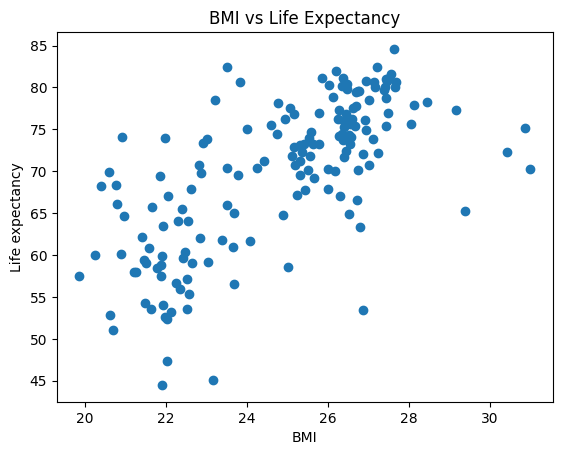

In [10]:
plt.scatter(X, y)
plt.xlabel("BMI")
plt.ylabel("Life expectancy")
plt.title("BMI vs Life Expectancy")
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [11]:
print("The relationship is generally increasing (positive relationship).")
print("As BMI increases, life expectancy tends to increase overall,")
print("but the pattern is not perfectly linear.")

The relationship is generally increasing (positive relationship).
As BMI increases, life expectancy tends to increase overall,
but the pattern is not perfectly linear.


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [12]:
linear_model = LinearRegression()

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [13]:
X_train_linear, X_test_linear, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

### Step 9. Train both models on the training set

In [14]:
linear_model.fit(X_train_linear, y_train)
poly_model.fit(X_train_poly, y_train_poly)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [15]:
linear_train_score = linear_model.score(X_train_linear, y_train)
poly_train_score = poly_model.score(X_train_poly, y_train_poly)

print("Linear Regression train R²:", linear_train_score)
print("Polynomial Regression train R²:", poly_train_score)

if poly_train_score > linear_train_score:
    print("Polynomial Regression performs better on the train set.")
else:
    print("Linear Regression performs better on the train set.")

Linear Regression train R²: 0.49395439141886677
Polynomial Regression train R²: 0.5143995545526131
Polynomial Regression performs better on the train set.


### Step 11. Evaluate and compare which of the two models score better on the `test` set

In [16]:
linear_test_score = linear_model.score(X_test_linear, y_test)
poly_test_score = poly_model.score(X_test_poly, y_test)

print("Linear Regression test R²:", linear_test_score)
print("Polynomial Regression test R²:", poly_test_score)

if poly_test_score > linear_test_score:
    print("Polynomial Regression performs better on the test set.")
else:
    print("Linear Regression performs better on the test set.")

Linear Regression test R²: 0.3540313361524452
Polynomial Regression test R²: 0.4031178873531288
Polynomial Regression performs better on the test set.
